## **TASK 1**

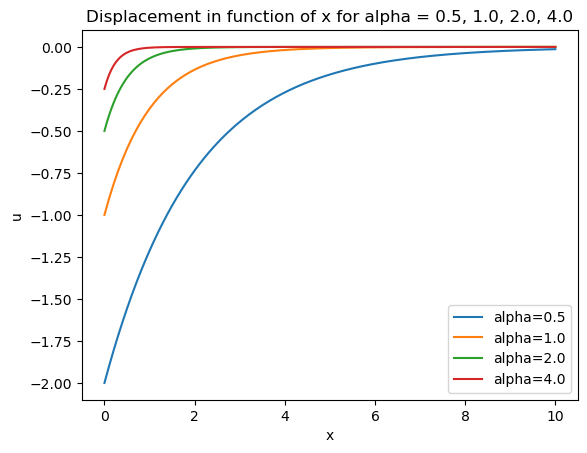

In [14]:
#!/usr/bin/env python

import numpy as np
import matplotlib.pyplot as plt

"""
Created: 2025/11/12 11:19:40
Last modified: 2025/11/12 11:53:33
Author: Francesco Bolzonella (francesco.bolzonella.1@studenti.unipd.it)
"""
# PREPROCESSOR

# Discretization definition
n_nodes = 200
x_values = np.linspace(0.0, 10.0, n_nodes)

# Constants of the bar in the domain x = 0 - 10
P, E, A = 1.0, 1.0, 1.0
L = 10.0
c = P * A / (L**2)
alpha_values = [
    0.5,
    1.0,
    2.0,
    4.0,
]
u = np.zeros((len(alpha_values), len(x_values)))

for i, alpha in enumerate(alpha_values):
    for j, x in enumerate(x_values):
        u[i, j] = -P / (E * A * alpha) * np.exp(-alpha * x)

# print(u)


# Plot of the graphs
for i in range(0, 4):
    plt.plot(x_values, u[i, :], linestyle="-", label=f"alpha={alpha_values[i]}")

    plt.xlabel("x")
    plt.ylabel("u")
    plt.title("Displacement in function of x for alpha = 0.5, 1.0, 2.0, 4.0")
plt.legend()

### **Considerations**

The parameter $\alpha$ represents the fundamental proper length scale of the mechanical system. It is defined as:
$$\alpha = \sqrt{\frac{k}{EA}}$$
where $k$ is the distributed stiffness of the elastic foundation and $EA$ is the axial stiffness of the bar. 
High values of $\alpha$ ($\alpha = 4.0$) indicate a system where the surrounding medium is extremely stiff relative to the bar. 
Low values of $\alpha$ ($\alpha = 0.5$) describe a comparatively rigid bar resting in a highly compliant (soft) medium.

The analytical curves show that the displacement $u(x)$ is concentrated near $x=0$ and reduces as it travels along the domain $L$. This localized region of severe gradients is a boundary layer. <br>
In the plots is shown that: <br>
* For $\alpha = 4.0$, the displacement field drops to almost zero within a very short distance from the origin. The load is entirely transferred to the surrounding foundation within this narrow band through shear stresses at the interface.
* For $\alpha = 0.5$, the decay is much more gradual.

The lowest error for a given discretization is therefore expected for lower $\alpha$ values due to the lower displacements localization near $x=0$ (lower steep gradient).

Since $u_{max} = \frac{P}{EA \alpha}$, an increase in $\alpha$ drastically reduces the maximum absolute displacement at $x=0$, this means that systems with high $\alpha$ values possess a much lower total strain energy, because the mechanical work performed by the external force $P \cdot u(0)$ is significantly smaller.

The steep gradients observed for higher $\alpha$ mathematically demonstrate that uniform spatial discretization (constant element size h) will be more inefficient than a graded one. The exact solution physically proves the necessity of localized mesh refinement (a graded mesh) near the load application point to minimize discretization error.

## **TASK 2**

##### ***Derivation of the Elementary Stiffness Matrices***

**The Local Weak Form**

The global Weak Form integrates over the entire bar $L$. By decomposing the domain into finite elements, we isolate the integral over a single element domain of length $h_e$:
$$\int_{x_1}^{x_2} EA \frac{du}{dx} \frac{dw}{dx} dx + \int_{x_1}^{x_2} k u w dx = \text{External Boundary Terms}$$

**The Galerkin Approximation**

Inside the element, the continuous unknown displacement $u(x)$ and the arbitrary test function $w(x)$ are approximated using a linear combination of shape functions $N(x)$ and nodal values.
For an element with $n$ nodes:
<u>Displacement field</u>: $u(x) \approx  u^h(x) = \sum_{j=1}^{n} N_j(x) u_j$ <br>
<u>Test function</u>: The test function must belong to the same space as the trial function. We choose $w(x) = N_i(x)$ for each node $i = 1, \dots, n$.

**Generating the Matrix Entries**

We substitute these approximations back into the local integral.

$K_{axial}$: <br>
Substituting $u(x)$ and $w(x)$ into the first integral yields the internal strain energy resistance:
$$\int_{x_1}^{x_2} EA \left( \sum_{j=1}^{n} \frac{dN_j}{dx} u_j \right) \frac{dN_i}{dx} dx$$
Due to the fact that the nodal displacements $u_j$ are constants with respect to the spatial integration, we can pull them out of the integral. This operation defines the element $(i, j)$ of the axial stiffness matrix:
$$(K^e_{axial})_{ij} = \int_{x_1}^{x_2} EA \frac{dN_i}{dx} \frac{dN_j}{dx} dx$$

$K_{mass}$: <br>
Substituting $u(x)$ and $w(x)$ into the second integral yields the resistance of the elastic medium:
$$\int_{x_1}^{x_2} k \left( \sum_{j=1}^{n} N_j(x) u_j \right) N_i(x) dx$$
Again, factoring out $u_j$ defines the element $(i, j)$ of the foundation matrix:
$$(K^e_{mass})_{ij} = \int_{x_1}^{x_2} k N_i(x) N_j(x) dx$$

The total elementary stiffness matrix is the sum of the two contributions: $[K^e] = [K^e_{axial}] + [K^e_{mass}]$.

**The Isoparametric Mapping and the Jacobian**

To evaluate these integrals algorithmically for any element, we map the physical coordinate $x \in [x_1, x_2]$ to a natural coordinate $\xi \in [-1, 1]$. 
The differential relationship is $dx = J d\xi$, where the Jacobian is $J = \frac{dx}{d\xi} = \frac{h_e}{2}$.
Consequently, the spatial derivatives map via the chain rule: 
$$\frac{dN}{dx} = \frac{dN}{d\xi} \frac{d\xi}{dx} = \frac{1}{J} \frac{dN}{d\xi}$$

By substituting the coordinate transformation into our matrix definitions, we obtain the exact algebraic forms implemented in finite element solvers:

<u>Axial Matrix</u>:
$$(K^e_{axial})_{ij} = \int_{-1}^{1} EA \left( \frac{1}{J} \frac{dN_i}{d\xi} \right) \left( \frac{1}{J} \frac{dN_j}{d\xi} \right) (J d\xi) = \frac{EA}{J} \int_{-1}^{1} \frac{dN_i}{d\xi} \frac{dN_j}{d\xi} d\xi$$

<u>Mass Matrix</u>:
$$(K^e_{mass})_{ij} = \int_{-1}^{1} k N_i(\xi) N_j(\xi) (J d\xi) = k J \int_{-1}^{1} N_i(\xi) N_j(\xi) d\xi$$

By evaluating these specific integrals using Gauss-Legendre quadrature, the numerical values of the matrix are perfectly defined.

**Explicit Evaluation for Linear Elements (2-Node)**

To demonstrate the exact outcome of these integrations, we perform the analytical evaluation for the standard linear isoparametric element. 
The element features two nodes with local coordinates $\xi_1 = -1$ and $\xi_2 = 1$. The corresponding linear shape functions are:
$$N_1(\xi) = \frac{1-\xi}{2}, \quad N_2(\xi) = \frac{1+\xi}{2}$$
The derivatives with respect to the natural coordinate are constant:
$$\frac{dN_1}{d\xi} = -\frac{1}{2}, \quad \frac{dN_2}{d\xi} = \frac{1}{2}$$

Substituting these geometric definitions into the mapped integral equations defined in Section 4, we evaluate the precise terms for the $2 \times 2$ elementary matrices.

$$[K^e_{axial}] = \frac{EA}{h_e} \begin{bmatrix} 1 & -1 \\ -1 & 1 \end{bmatrix}$$

$$[K^e_{mass}] = \frac{k h_e}{6} \begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix}$$

The total algebraic stiffness matrix for the 2-node element is:
$$[K^e] = \frac{EA}{h_e} \begin{bmatrix} 1 & -1 \\ -1 & 1 \end{bmatrix} + \frac{k h_e}{6} \begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix}$$

**6. Explicit Evaluation for Quadratic Elements (3-Node)**

In the natural coordinate system, for a 3 node element, the positions are defined as $\xi_1 = -1$, $\xi_2 = 0$, and $\xi_3 = 1$. The corresponding parabolic shape functions are:
$$N_1(\xi) = \frac{1}{2}\xi(\xi-1), \quad N_2(\xi) = 1-\xi^2, \quad N_3(\xi) = \frac{1}{2}\xi(\xi+1)$$

The derivatives with respect to the natural coordinate are:
$$\frac{dN_1}{d\xi} = \xi - \frac{1}{2}, \quad \frac{dN_2}{d\xi} = -2\xi, \quad \frac{dN_3}{d\xi} = \xi + \frac{1}{2}$$

Substituting these quadratic geometric definitions into the mapped integral equations and doing the definite integrations over $[-1, 1]$:

$$[K^e_{axial}] = \frac{EA}{3 h_e} \begin{bmatrix} 7 & -8 & 1 \\ -8 & 16 & -8 \\ 1 & -8 & 7 \end{bmatrix}$$

$$[K^e_{mass}] = \frac{k h_e}{30} \begin{bmatrix} 4 & 2 & -1 \\ 2 & 16 & 2 \\ -1 & 2 & 4 \end{bmatrix}$$

The total algebraic stiffness matrix for the 3-node element is:
$$[K^e] = \frac{EA}{3 h_e} \begin{bmatrix} 7 & -8 & 1 \\ -8 & 16 & -8 \\ 1 & -8 & 7 \end{bmatrix} + \frac{k h_e}{30} \begin{bmatrix} 4 & 2 & -1 \\ 2 & 16 & 2 \\ -1 & 2 & 4 \end{bmatrix}$$

### (bar_1D with 2 nodes)

In [13]:
#!/usr/bin/env python

import numpy as np

import pyfem


def main(use_sparse: bool = True) -> None:
    # PREPROCESSING

    # 1. Geometry and discretization

    # Problem parameters
    L = 10.0
    number_elements = np.array([1.0])
    P = 1.0
    E = 1.0
    A = 1.0
    alpha_values = np.array([1.0])

    # Connectivity generation
    element_connectivity = element_connectivity = [
        [0, 1],
    ]

    # Initialization of the vectors before the cicles
    epsilon_h = np.zeros((len(alpha_values), len(number_elements)))
    epsilon = np.zeros((len(alpha_values), len(number_elements)))
    e = np.zeros((len(alpha_values), len(number_elements)))

    for alpha in alpha_values:
        alpha_counter = np.where(alpha_values == alpha)[0][0]
        # 2. Element properties

        # Define element properties registry
        element_properties = pyfem.make_element_properties(
            [
                ("bar", ("bar_1D", {"E": E, "A": A, "k": alpha**2 * E * A})),
            ]
        )

        for Ne in number_elements:
            num_elements = int(Ne)
            # Found the position in number_elements of num_elements
            i = np.where(number_elements == num_elements)[0][0]

            # Assign properties to elements
            element_property_labels = ["bar"] * num_elements

            # Nodes and points calculation
            num_nodes = int((1.0 * Ne) + 1)
            points = np.linspace(0.0, L, num_nodes)

            # 3. Mesh

            # Create mesh
            mesh = pyfem.Mesh(
                num_nodes=num_nodes,
                points=points,
                num_elements=num_elements,
                element_connectivity=element_connectivity,
                element_property_labels=element_property_labels,
            )

            # Define node sets
            mesh.add_node_set(tag=1, nodes={0}, name="left_end")
            mesh.add_node_set(tag=2, nodes={num_nodes - 1}, name="right_end")

            print("\n- Node sets:")

            for tag, node_set in mesh.node_sets.items():
                print(f"  {node_set}")

            # 4. Create Model

            problem = pyfem.Problem(
                pyfem.Physics.MECHANICS,
                pyfem.Dimension.D1,
            )

            model = pyfem.Model(mesh, problem)
            model.set_element_properties(element_properties)
            print(model)

            # 5. Boundary conditions

            # Dirichlet boundary conditions (prescribed displacements)
            model.bc.prescribe_displacement(
                "right_end",
                pyfem.DOFType.U_X,
                (-(P / (E * A * alpha)) * np.exp(-alpha * 10.0)),
            )

            # Neumann boundary conditions (applied forces)
            model.bc.apply_force("left_end", pyfem.DOFType.U_X, -P)

            print(f"\n- Prescribed displacements: {model.bc.prescribed_displacements}")
            print(f"- Applied forces: {model.bc.applied_forces}")

            # PROCESSING: Solve FEA problem

            # Create solver
            solver = pyfem.LinearStaticSolver(model)

            # Assemble the global stiffness matrix
            solver.assemble_global_matrix()

            # Apply boundary conditions
            solver.apply_boundary_conditions()

            # Solve for nodal displacements
            solver.solve()

            print("\n- Nodal displacements U:")
            print(solver.nodal_displacements)

            # POSTPROCESSING: Compute derived quantities

            # Create postprocessor
            postprocessor = pyfem.PostProcessor(
                model.mesh,
                model.element_properties,
                solver.global_stiffness_matrix,
                solver.nodal_displacements,
                number_elements,
                alpha,
                alpha_counter,
                alpha_values,
                E,
                A,
                P,
            )

            # Compute strain energy using the global solution (U = 0.5 * u^T * K * u)
            epsilon_h = postprocessor.compute_strain_energy_global(i, epsilon_h)

            # Compute the analytical strain energy
            epsilon = postprocessor.compute_strain_energy_analytical(i, epsilon)

            # Computes the relative error in the energy norm
            e = postprocessor.compute_relative_error_in_energy(i, epsilon, epsilon_h, e)


if __name__ == "__main__":
    main(use_sparse=False)



- Node sets:
  NodeSet(tag=1, num_nodes=1, name='left_end')
  NodeSet(tag=2, num_nodes=1, name='right_end')

Model Summary:
  Problem Type: Mechanics (1D) - DOFs: [u_x]
  Mesh: 2 nodes, 1 elements
  Degrees of Freedom: 2
  Node Sets: 2

- Prescribed displacements: [(1, np.float64(-4.5399929762484854e-05))]
- Applied forces: [(0, -1.0)]

- Nodal displacements U:
[-2.91241419e-01 -4.53999298e-05]


### bar_1D with 3 nodes

In [12]:
#!/usr/bin/env python

import numpy as np

import pyfem


def main(use_sparse: bool = True) -> None:
    # PREPROCESSING

    # 1. Geometry and discretization

    # Problem parameters
    L = 10.0
    number_elements = np.array([1.0])
    P = 1.0
    E = 1.0
    A = 1.0
    alpha_values = np.array([1.0])

    # Connectivity generation
    element_connectivity = element_connectivity = [
        [0, 1, 2],
    ]

    # Initialization of the vectors before the cicles
    epsilon_h = np.zeros((len(alpha_values), len(number_elements)))
    epsilon = np.zeros((len(alpha_values), len(number_elements)))
    e = np.zeros((len(alpha_values), len(number_elements)))

    for alpha in alpha_values:
        alpha_counter = np.where(alpha_values == alpha)[0][0]
        # 2. Element properties

        # Define element properties registry
        element_properties = pyfem.make_element_properties(
            [
                ("bar", ("bar3_1D", {"E": E, "A": A, "k": alpha**2 * E * A})),
            ]
        )

        for Ne in number_elements:
            num_elements = int(Ne)
            # Found the position in number_elements of num_elements
            i = np.where(number_elements == num_elements)[0][0]

            # Assign properties to elements
            element_property_labels = ["bar"] * num_elements

            # Nodes and points calculation
            num_nodes = int((2.0 * Ne) + 1)
            points = np.linspace(0.0, L, num_nodes)

            # 3. Mesh

            # Create mesh
            mesh = pyfem.Mesh(
                num_nodes=num_nodes,
                points=points,
                num_elements=num_elements,
                element_connectivity=element_connectivity,
                element_property_labels=element_property_labels,
            )

            # Define node sets
            mesh.add_node_set(tag=1, nodes={0}, name="left_end")
            mesh.add_node_set(tag=2, nodes={num_nodes - 1}, name="right_end")

            print("\n- Node sets:")

            for tag, node_set in mesh.node_sets.items():
                print(f"  {node_set}")

            # 4. Create Model

            problem = pyfem.Problem(
                pyfem.Physics.MECHANICS,
                pyfem.Dimension.D1,
            )

            model = pyfem.Model(mesh, problem)
            model.set_element_properties(element_properties)
            print(model)

            # 5. Boundary conditions

            # Dirichlet boundary conditions (prescribed displacements)
            model.bc.prescribe_displacement(
                "right_end",
                pyfem.DOFType.U_X,
                (-(P / (E * A * alpha)) * np.exp(-alpha * 10.0)),
            )

            # Neumann boundary conditions (applied forces)
            model.bc.apply_force("left_end", pyfem.DOFType.U_X, -P)

            print(f"\n- Prescribed displacements: {model.bc.prescribed_displacements}")
            print(f"- Applied forces: {model.bc.applied_forces}")

            # PROCESSING: Solve FEA problem

            # Create solver
            solver = pyfem.LinearStaticSolver(model)

            # Assemble the global stiffness matrix
            solver.assemble_global_matrix()

            # Apply boundary conditions
            solver.apply_boundary_conditions()

            # Solve for nodal displacements
            solver.solve()

            print("\n- Nodal displacements U:")
            print(solver.nodal_displacements)

            # POSTPROCESSING: Compute derived quantities

            # Create postprocessor
            postprocessor = pyfem.PostProcessor(
                model.mesh,
                model.element_properties,
                solver.global_stiffness_matrix,
                solver.nodal_displacements,
                number_elements,
                alpha,
                alpha_counter,
                alpha_values,
                E,
                A,
                P,
            )

            # Compute strain energy using the global solution (U = 0.5 * u^T * K * u)
            epsilon_h = postprocessor.compute_strain_energy_global(i, epsilon_h)

            # Compute the analytical strain energy
            epsilon = postprocessor.compute_strain_energy_analytical(i, epsilon)

            # Computes the relative error in the energy norm
            e = postprocessor.compute_relative_error_in_energy(i, epsilon, epsilon_h, e)


if __name__ == "__main__":
    main(use_sparse=False)



- Node sets:
  NodeSet(tag=1, num_nodes=1, name='left_end')
  NodeSet(tag=2, num_nodes=1, name='right_end')

Model Summary:
  Problem Type: Mechanics (1D) - DOFs: [u_x]
  Mesh: 3 nodes, 1 elements
  Degrees of Freedom: 3
  Node Sets: 2

- Prescribed displacements: [(2, np.float64(-4.5399929762484854e-05))]
- Applied forces: [(0, -1.0)]

- Nodal displacements U:
[-6.49615951e-01  4.42950921e-02 -4.53999298e-05]


## **TASK 3**


- Node sets:
  NodeSet(tag=1, num_nodes=1, name='left_end')
  NodeSet(tag=2, num_nodes=1, name='right_end')

Model Summary:
  Problem Type: Mechanics (1D) - DOFs: [u_x]
  Mesh: 5 nodes, 4 elements
  Degrees of Freedom: 5
  Node Sets: 2

- Prescribed displacements: [(4, np.float64(-4.5399929762484854e-05))]
- Applied forces: [(0, -1.0)]


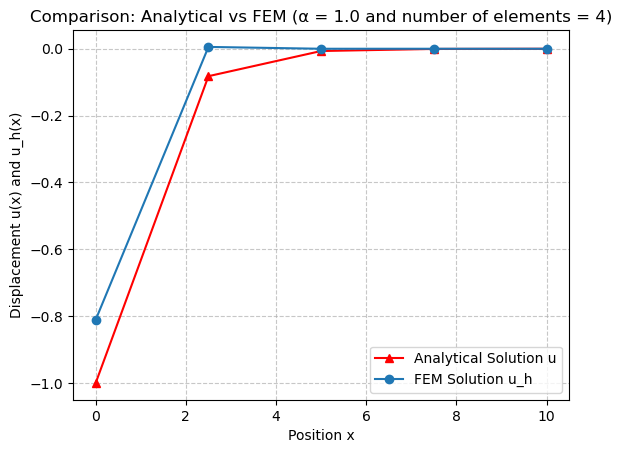


- Node sets:
  NodeSet(tag=1, num_nodes=1, name='left_end')
  NodeSet(tag=2, num_nodes=1, name='right_end')

Model Summary:
  Problem Type: Mechanics (1D) - DOFs: [u_x]
  Mesh: 9 nodes, 8 elements
  Degrees of Freedom: 9
  Node Sets: 2

- Prescribed displacements: [(8, np.float64(-4.5399929762484854e-05))]
- Applied forces: [(0, -1.0)]


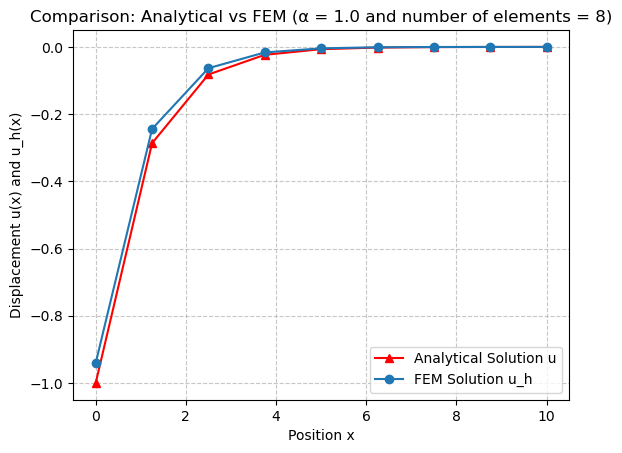


- Node sets:
  NodeSet(tag=1, num_nodes=1, name='left_end')
  NodeSet(tag=2, num_nodes=1, name='right_end')

Model Summary:
  Problem Type: Mechanics (1D) - DOFs: [u_x]
  Mesh: 17 nodes, 16 elements
  Degrees of Freedom: 17
  Node Sets: 2

- Prescribed displacements: [(16, np.float64(-4.5399929762484854e-05))]
- Applied forces: [(0, -1.0)]


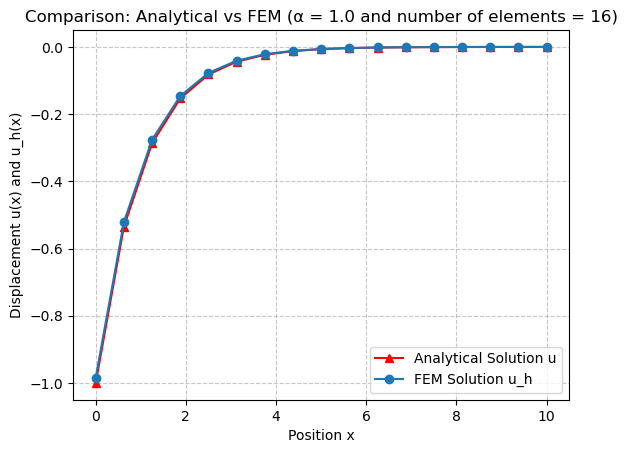


- Node sets:
  NodeSet(tag=1, num_nodes=1, name='left_end')
  NodeSet(tag=2, num_nodes=1, name='right_end')

Model Summary:
  Problem Type: Mechanics (1D) - DOFs: [u_x]
  Mesh: 33 nodes, 32 elements
  Degrees of Freedom: 33
  Node Sets: 2

- Prescribed displacements: [(32, np.float64(-4.5399929762484854e-05))]
- Applied forces: [(0, -1.0)]


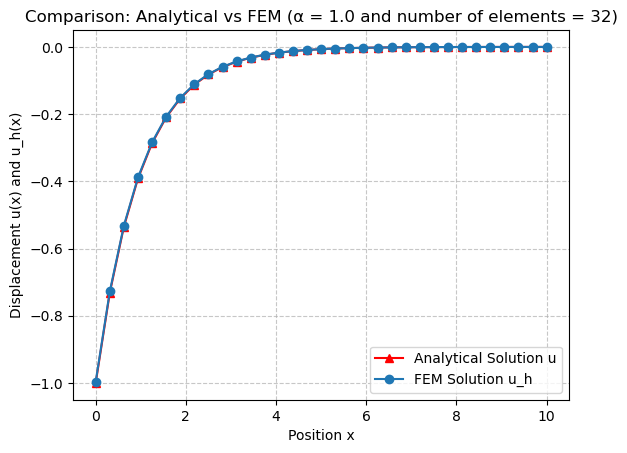


- Node sets:
  NodeSet(tag=1, num_nodes=1, name='left_end')
  NodeSet(tag=2, num_nodes=1, name='right_end')

Model Summary:
  Problem Type: Mechanics (1D) - DOFs: [u_x]
  Mesh: 65 nodes, 64 elements
  Degrees of Freedom: 65
  Node Sets: 2

- Prescribed displacements: [(64, np.float64(-4.5399929762484854e-05))]
- Applied forces: [(0, -1.0)]


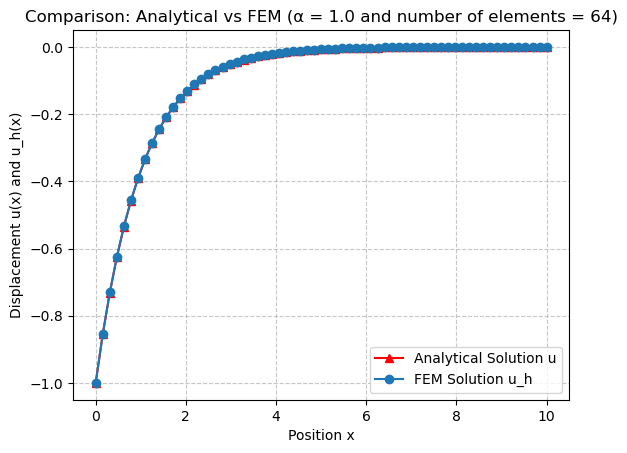

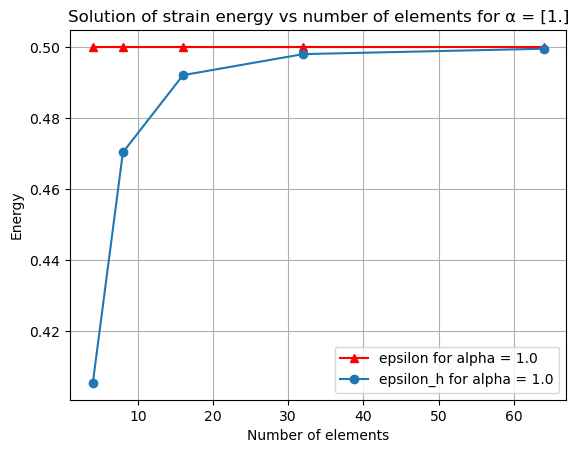

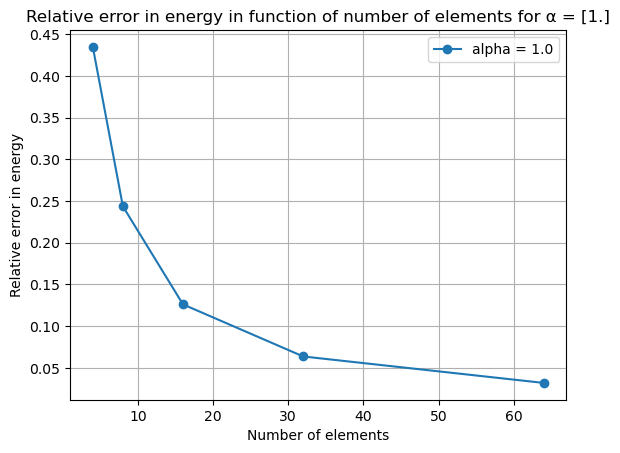

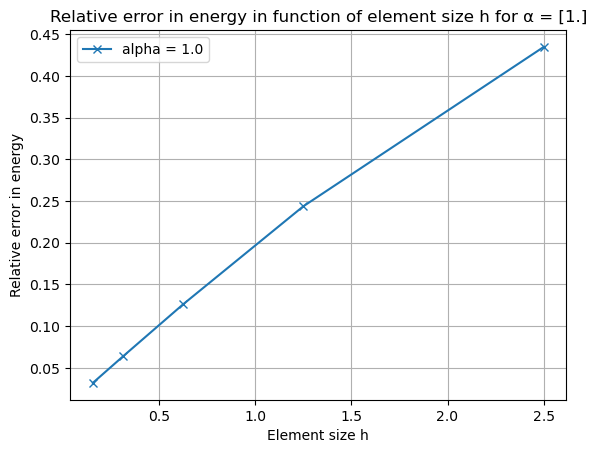

In [ ]:
#!/usr/bin/env python

import numpy as np

import pyfem


def connectivity_2nodes_per_element(Ne: int) -> list:
    """
    Genera la connettività per una mesh 1D uniforme con Ne elementi a due nodi.

    Args:
        Ne: Numero di elementi.

    Returns:
        Una lista di liste che definisce la connettività degli elementi.
    """

    # 1. Crea un array di indici da 0 a Ne (i nodi iniziali)
    nodi_iniziali = np.arange(Ne)  # [0, 1, 2, ..., Ne-1]

    # 2. Crea un array per i nodi finali (da 1 a Ne)
    nodi_finali = np.arange(1, Ne + 1)  # [1, 2, 3, ..., Ne]

    # 3. Combina i due array in una lista di coppie (connettività)
    #    numpy.column_stack crea una matrice a due colonne,
    #    poi la convertiamo in una lista di liste.
    element_connectivity = np.column_stack((nodi_iniziali, nodi_finali)).tolist()

    return element_connectivity


def main(use_sparse: bool = True) -> None:
    # PREPROCESSING

    # 1. Geometry and discretization

    # Problem parameters
    L = 10.0
    number_elements = np.array([4.0, 8.0, 16.0, 32.0, 64.0])
    h = L / number_elements
    P = 1.0
    E = 1.0
    A = 1.0
    alpha_values = np.array([1.0])

    # Initialization of the vectors before the cicles
    epsilon = np.zeros((len(alpha_values), len(number_elements)))
    epsilon_h = np.zeros((len(alpha_values), len(number_elements)))
    e = np.zeros((len(alpha_values), len(number_elements)))

    for alpha in alpha_values:
        alpha_counter = np.where(alpha_values == alpha)[0][0]

        # 2. Element properties

        # Define element properties registry
        element_properties = pyfem.make_element_properties(
            [
                ("bar", ("bar_1D", {"E": E, "A": A, "k": alpha**2 * E * A})),
            ]
        )

        for Ne in number_elements:
            num_elements = int(Ne)

            # Found the position in number_elements of num_elements
            i = np.where(number_elements == num_elements)[0][0]

            # Assign properties to elements
            element_property_labels = ["bar"] * num_elements

            # Nodes and points calculation
            num_nodes = int(Ne + 1)
            points = np.linspace(0.0, 10.0, num_nodes)

            # Connectivity generation
            element_connectivity = connectivity_2nodes_per_element(int(Ne))

            # 3. Mesh

            # Create mesh
            mesh = pyfem.Mesh(
                num_nodes=num_nodes,
                points=points,
                num_elements=num_elements,
                element_connectivity=element_connectivity,
                element_property_labels=element_property_labels,
            )

            # Define node sets
            mesh.add_node_set(tag=1, nodes={0}, name="left_end")
            mesh.add_node_set(tag=2, nodes={num_nodes - 1}, name="right_end")

            print("\n- Node sets:")

            for tag, node_set in mesh.node_sets.items():
                print(f"  {node_set}")

            # 4. Create Model

            problem = pyfem.Problem(
                pyfem.Physics.MECHANICS,
                pyfem.Dimension.D1,
            )

            model = pyfem.Model(mesh, problem)
            model.set_element_properties(element_properties)
            print(model)

            # 5. Boundary conditions

            # Dirichlet boundary conditions (prescribed displacements)
            model.bc.prescribe_displacement(
                "right_end",
                pyfem.DOFType.U_X,
                (-(P / (E * A * alpha)) * np.exp(-alpha * 10.0)),
            )

            # Neumann boundary conditions (applied forces)
            model.bc.apply_force("left_end", pyfem.DOFType.U_X, -P)

            print(f"\n- Prescribed displacements: {model.bc.prescribed_displacements}")
            print(f"- Applied forces: {model.bc.applied_forces}")

            # PROCESSING: Solve FEA problem

            # Create solver
            solver = pyfem.LinearStaticSolver(model)

            # Assemble the global stiffness matrix
            solver.assemble_global_matrix()

            # Apply boundary conditions
            solver.apply_boundary_conditions()

            # Solve for nodal displacements
            solver.solve()

            # POSTPROCESSING: Compute derived quantities

            # Create postprocessor
            postprocessor = pyfem.PostProcessor(
                model.mesh,
                model.element_properties,
                solver.global_stiffness_matrix,
                solver.nodal_displacements,
                number_elements,
                alpha,
                alpha_counter,
                alpha_values,
                E,
                A,
                P,
            )

            # Plot of the displacements solution
            postprocessor.plot_u_uh(num_elements, L)

            # Compute strain energy using the global solution (U = 0.5 * u^T * K * u)
            epsilon_h = postprocessor.compute_strain_energy_global(i, epsilon_h)

            # Compute the analytical strain energy
            epsilon = postprocessor.compute_strain_energy_analytical(i, epsilon)

            # Computes the relative error in the energy norm
            e = postprocessor.compute_relative_error_in_energy(i, epsilon, epsilon_h, e)

    # Plots the solution of the energy
    postprocessor.plot_solution(epsilon, epsilon_h)
    # Plots the relative error in the energy
    postprocessor.plot_e(e, h)


if __name__ == "__main__":
    main(use_sparse=False)


### **Observations and Discussion**

Based on the plotted results, the following physical and numerical observations can be made:

* <u>Coarse Mesh</u>: When the domain is discretized with only a few elements, the element size h is mathematically too large to capture the steep exponential decay. Due to the interpolation of linear 2-node elements using straight lines, they "cut across" the high-curvature region near the load, leading to a significant discretization error and a "wrong" numerical response that fails to show the local physics accurately.

* <u>Refined Mesh </u>: As the number of elements increases and h decreases, the linear segments become small enough to better approach the analytical curve. For $N=64$, the numerical solution reach closely the exact displacement, showing that the h-refinement strategy eventually gives the correct field.

* <u>Computational Inefficiency</u>: Although increasing N improves accuracy, the plots highlight an intrinsic inefficiency in the uniform refinement approach. To properly resolve the gradient at $x=0$, we are forced to use a very fine mesh across the entire bar. Consequently, for $N=64$, dozens of elements are placed in the region $x > 2$ where the displacement is already negligible, and these elements increase the number of Degrees of Freedom (and thus the computational cost) without providing any meaningful gain in global accuracy.

## **TASK 4**

### bar_1D with 2 nodes

C:\Users\bolzo\AppData\Local\Temp\ipykernel_852\1323684881.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  alpha = float(alpha_values)


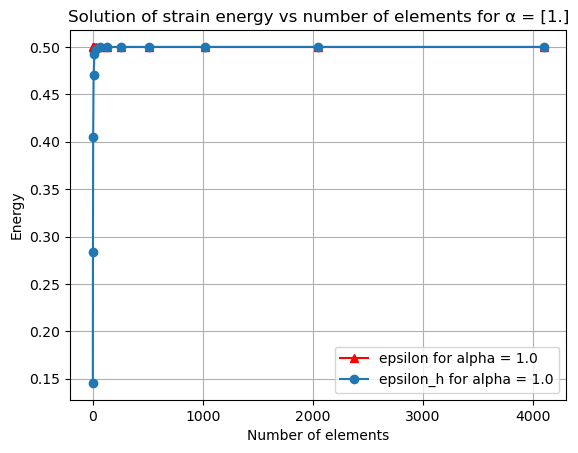

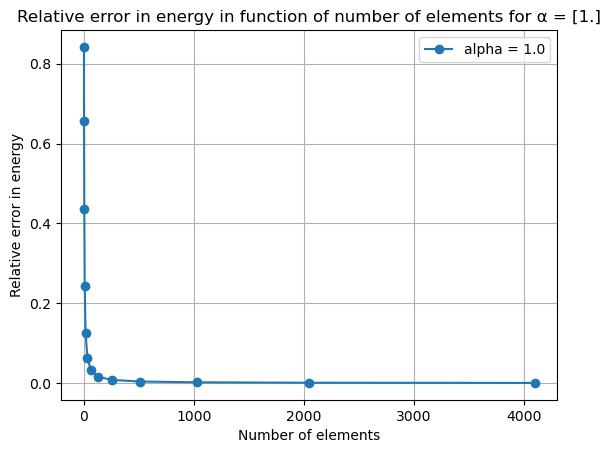

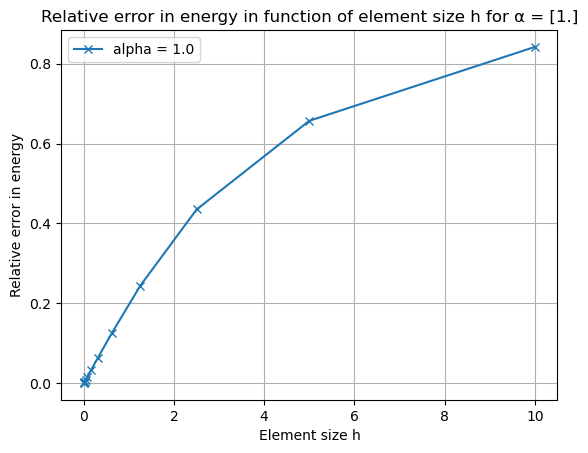

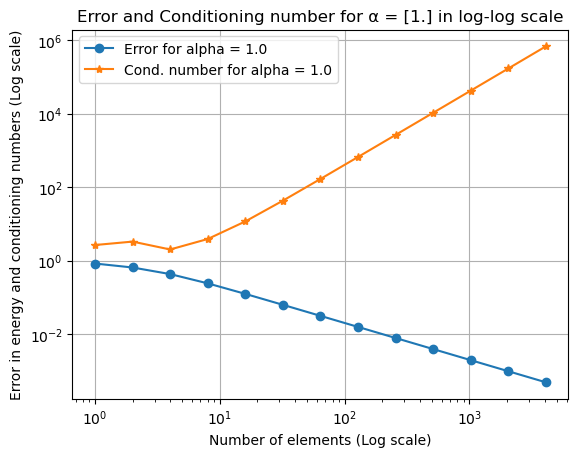

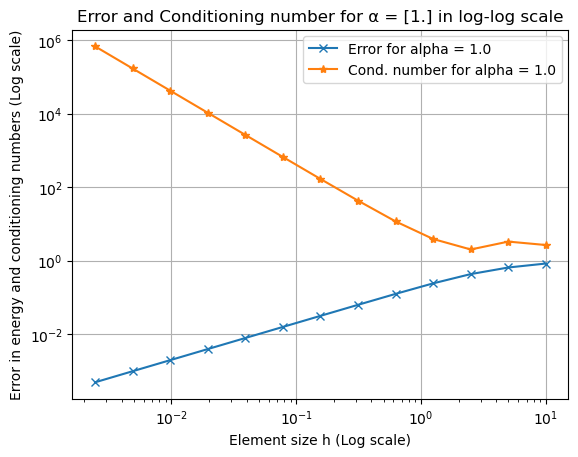

- Convergence rate for alpha = 1.0: 1.0000


In [7]:
#!/usr/bin/env python

import numpy as np
import scipy.sparse.linalg as spla

import pyfem


def conditioning_numbers_of_K(
    alpha_counter: int, cond_numbers: np.ndarray, K: np.ndarray, i: int
) -> np.ndarray:
    """
    Computes the conditioning number of the matrix K.
    It's a matrix and every row is related to a different value of alpha.

    Returns:
        cond_numbers.
    """

    # 1. Calcola l'autovalore massimo (k=1, Largest Magnitude)
    # return_eigenvectors=False risparmia memoria
    max_eig = spla.norm(K, np.inf)

    # 2. Calcola l'autovalore minimo (k=1, Smallest Magnitude)
    # sigma=0 usa lo shift-invert mode che è molto più veloce per trovare valori vicino allo 0

    try:
        min_eig = spla.eigsh(
            K,
            k=1,
            sigma=0,  # Shift-Invert (cerca l'inverso, velocissimo per il minimo)
            which="LM",  # Largest Magnitude dell'inverso
            return_eigenvectors=False,
            tol=1e-2,  # FONDAMENTALE: Ci accontentiamo dell'1% di errore
            ncv=10,  # Aumentiamo i vettori di Lanczos per convergere in meno iterazioni
        )[0]

        # Se min_eig è troppo vicino a zero, evita divisioni assurde
        if abs(min_eig) < 1e-15:
            c = np.inf
        else:
            c = abs(max_eig / min_eig)

    except (RuntimeError, ValueError):
        # Se il calcolo esplode (matrice singolare), il condizionamento è infinito
        c = np.inf

    # 3. Salva il risultato nella matrice e restituisci la matrice
    cond_numbers[alpha_counter, i] = c

    return cond_numbers


def main(use_sparse: bool = False) -> None:
    # PREPROCESSING

    # 1. Geometry and discretization

    # Problem parameters
    L = 10.0
    number_elements = np.zeros(13)
    for n in range(0, 13):
        number_elements[n] = 2**n
    h = L / number_elements
    P = 1.0
    E = 1.0
    A = 1.0
    alpha_values = np.array([1.0])
    alpha = float(alpha_values)
    alpha_counter = np.where(alpha_values == alpha)[0][0]
    cond_numbers = np.zeros((len(alpha_values), len(number_elements)))

    epsilon = (P / (2.0 * alpha * E * A)) * (-np.exp(-20.0 * alpha) + 1.0)

    # 2. Element properties

    # Define element properties registry
    element_properties = pyfem.make_element_properties(
        [
            ("bar", ("bar_1D", {"E": E, "A": A, "k": alpha**2 * E * A})),
        ]
    )

    # Initialization of the vectors before the for cicle
    epsilon = np.zeros((1, len(number_elements)))
    epsilon_h = np.zeros((1, len(number_elements)))
    e = np.zeros((1, len(number_elements)))

    for Ne in number_elements:
        num_elements = int(Ne)

        # Found the position in number_elements of num_elements
        i = np.where(number_elements == num_elements)[0][0]

        # Assign properties to elements
        element_property_labels = ["bar"] * num_elements

        # Nodes and points calculation
        num_nodes = int(Ne + 1)
        points = np.linspace(0.0, 10.0, num_nodes)

        # Connectivity generation
        element_connectivity = connectivity_2nodes_per_element(int(Ne))

        # 3. Mesh

        # Create mesh
        mesh = pyfem.Mesh(
            num_nodes=num_nodes,
            points=points,
            num_elements=num_elements,
            element_connectivity=element_connectivity,
            element_property_labels=element_property_labels,
        )

        # Define node sets
        mesh.add_node_set(tag=1, nodes={0}, name="left_end")
        mesh.add_node_set(tag=2, nodes={num_nodes - 1}, name="right_end")

        # 4. Create Model

        problem = pyfem.Problem(
            pyfem.Physics.MECHANICS,
            pyfem.Dimension.D1,
        )

        model = pyfem.Model(mesh, problem)
        model.set_element_properties(element_properties)

        # 5. Boundary conditions

        # Dirichlet boundary conditions (prescribed displacements)
        model.bc.prescribe_displacement(
            "right_end",
            pyfem.DOFType.U_X,
            (-(P / (E * A * alpha)) * np.exp(-alpha * 10.0)),
        )

        # Neumann boundary conditions (applied forces)
        model.bc.apply_force("left_end", pyfem.DOFType.U_X, -P)

        # PROCESSING: Solve FEA problem

        # Create solver
        solver = pyfem.LinearStaticSolver(model)

        # Assemble the global stiffness matrix
        solver.assemble_global_matrix()

        # Apply boundary conditions
        solver.apply_boundary_conditions()

        # Solve for nodal displacements
        solver.solve()

        # POSTPROCESSING: Compute derived quantities

        # Create postprocessor
        postprocessor = pyfem.PostProcessor(
            model.mesh,
            model.element_properties,
            solver.global_stiffness_matrix,
            solver.nodal_displacements,
            number_elements,
            alpha,
            alpha_counter,
            alpha_values,
            E,
            A,
            P,
        )

        # Compute strain energy using the global solution (U = 0.5 * u^T * K * u)
        epsilon_h = postprocessor.compute_strain_energy_global(i, epsilon_h)

        # Compute the analytical strain energy
        epsilon = postprocessor.compute_strain_energy_analytical(i, epsilon)

        # Computes the relative error in the energy norm
        e = postprocessor.compute_relative_error_in_energy(i, epsilon, epsilon_h, e)

        # Compute the conditioning number of K
        cond_numbers = conditioning_numbers_of_K(
            alpha_counter, cond_numbers, solver.global_stiffness_matrix, i
        )

    # Plots the solution of the energy
    postprocessor.plot_solution(epsilon, epsilon_h)
    # Plots the relative error in the energy
    postprocessor.plot_e(e, h)
    # Plots the relative error in the energy
    postprocessor.plot_convergence_rate(e, h, cond_numbers)
    # Compute the convergence rate
    postprocessor.calculate_convergence_rates(e, h, is_dofs=False)


if __name__ == "__main__":
    main(use_sparse=False)


### bar_1D with 3 nodes

C:\Users\bolzo\AppData\Local\Temp\ipykernel_852\3948605976.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  alpha = float(alpha_values)


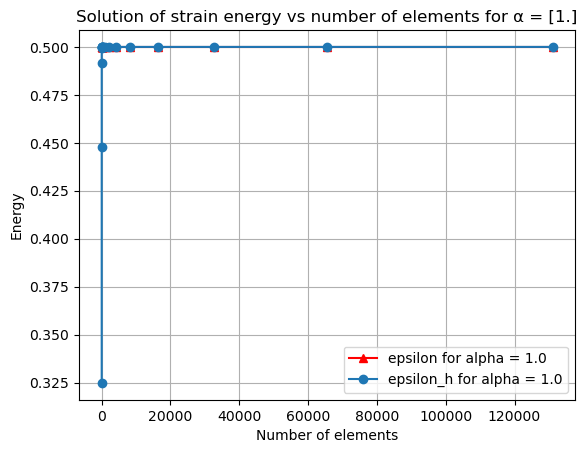

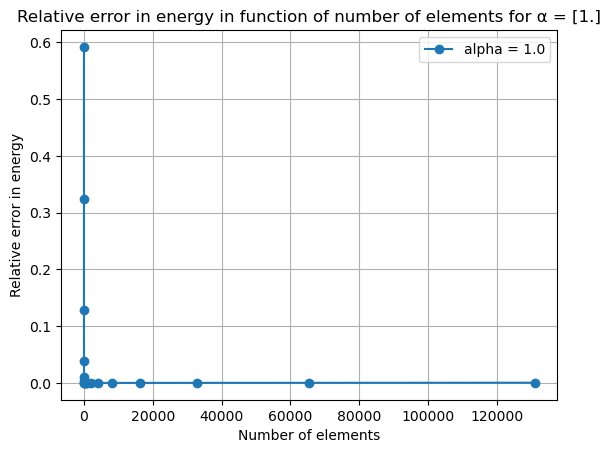

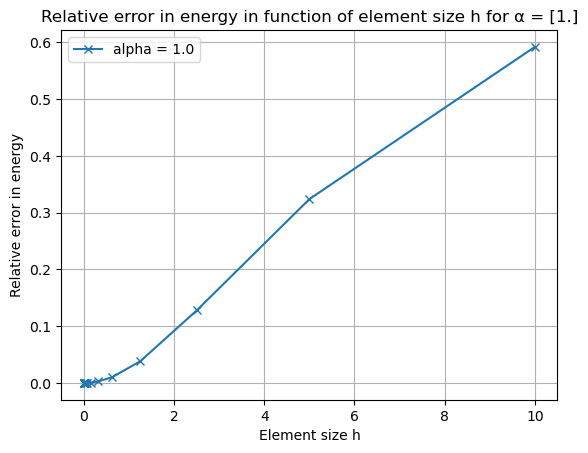

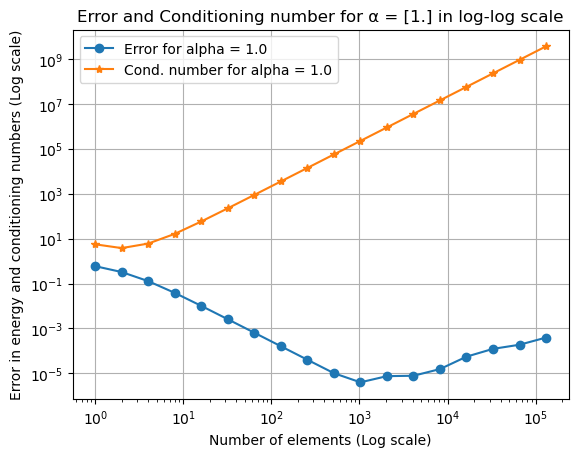

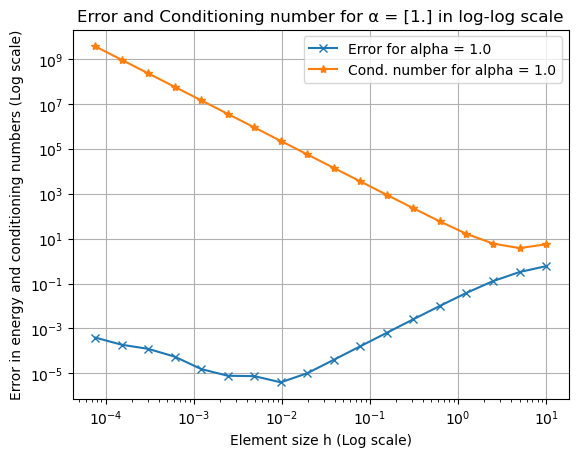

- Convergence rate for alpha = 1.0: 1.9879


In [6]:
#!/usr/bin/env python

import numpy as np
import scipy.sparse.linalg as spla

import pyfem


def connectivity_3nodes_per_element(Ne: int) -> list[list[int]]:
    """
    Generates the connectivity matrix for 1D quadratic elements (3 nodes).

    Parameters:
    Ne (int): Number of finite elements in the mesh.

    Returns:
    element_connectivity (list[list[int]]): A matrix of size (n_elements x 3) containing integer node indices.
    """
    # 1. Initialize the matrix
    element_connectivity = []

    # 2. Fill the matrix
    for element in range(Ne):
        start_node = 2 * element
        # Crea una lista per il singolo elemento [n1, n2, n3]
        element_nodes = [start_node, start_node + 1, start_node + 2]

        # Aggiungila alla lista principale
        element_connectivity.append(element_nodes)

    return element_connectivity


def main(use_sparse: bool = True) -> None:
    # PREPROCESSING

    # 1. Geometry and discretization

    # Problem parameters
    L = 10.0
    number_elements = np.zeros(18)
    for n in range(0, 18):
        number_elements[n] = 2**n
    h = L / number_elements
    P = 1.0
    E = 1.0
    A = 1.0
    alpha_values = np.array([1.0])
    alpha = float(alpha_values)
    alpha_counter = np.where(alpha_values == alpha)[0][0]
    cond_numbers = np.zeros((len(alpha_values), len(number_elements)))

    epsilon = (P / (2.0 * alpha * E * A)) * (-np.exp(-20.0 * alpha) + 1.0)

    # 2. Element properties

    # Define element properties registry
    element_properties = pyfem.make_element_properties(
        [
            ("bar", ("bar3_1D", {"E": E, "A": A, "k": alpha**2 * E * A})),
        ]
    )

    # Initialization of the vectors before the for cicle
    epsilon = np.zeros((1, len(number_elements)))
    epsilon_h = np.zeros((1, len(number_elements)))
    e = np.zeros((1, len(number_elements)))

    for Ne in number_elements:
        num_elements = int(Ne)
        # Found the position in number_elements of num_elements
        i = np.where(number_elements == num_elements)[0][0]

        # Assign properties to elements
        element_property_labels = ["bar"] * num_elements

        # Nodes and points calculation
        num_nodes = int((2.0 * Ne) + 1)
        points = np.linspace(0.0, 10.0, num_nodes)

        # Connectivity generation
        element_connectivity = connectivity_3nodes_per_element(int(Ne))

        # 3. Mesh

        # Create mesh
        mesh = pyfem.Mesh(
            num_nodes=num_nodes,
            points=points,
            num_elements=num_elements,
            element_connectivity=element_connectivity,
            element_property_labels=element_property_labels,
        )

        # Define node sets
        mesh.add_node_set(tag=1, nodes={0}, name="left_end")
        mesh.add_node_set(tag=2, nodes={num_nodes - 1}, name="right_end")

        # 4. Create Model

        problem = pyfem.Problem(
            pyfem.Physics.MECHANICS,
            pyfem.Dimension.D1,
        )

        model = pyfem.Model(mesh, problem)
        model.set_element_properties(element_properties)

        # 5. Boundary conditions

        # Dirichlet boundary conditions (prescribed displacements)
        model.bc.prescribe_displacement(
            "right_end",
            pyfem.DOFType.U_X,
            (-(P / (E * A * alpha)) * np.exp(-alpha * 10.0)),
        )

        # Neumann boundary conditions (applied forces)
        model.bc.apply_force("left_end", pyfem.DOFType.U_X, -P)

        # PROCESSING: Solve FEA problem

        # Create solver
        solver = pyfem.LinearStaticSolver(model)

        # Assemble the global stiffness matrix
        solver.assemble_global_matrix()

        # Apply boundary conditions
        solver.apply_boundary_conditions()

        # Solve for nodal displacements
        solver.solve()

        # POSTPROCESSING: Compute derived quantities

        # Create postprocessor
        postprocessor = pyfem.PostProcessor(
            model.mesh,
            model.element_properties,
            solver.global_stiffness_matrix,
            solver.nodal_displacements,
            number_elements,
            alpha,
            alpha_counter,
            alpha_values,
            E,
            A,
            P,
        )

        # Compute strain energy using the global solution (U = 0.5 * u^T * K * u)
        epsilon_h = postprocessor.compute_strain_energy_global(i, epsilon_h)

        # Compute the analytical strain energy
        epsilon = postprocessor.compute_strain_energy_analytical(i, epsilon)

        # Computes the relative error in the energy norm
        e = postprocessor.compute_relative_error_in_energy(i, epsilon, epsilon_h, e)

        # Compute the conditioning number of K
        cond_numbers = conditioning_numbers_of_K(
            alpha_counter, cond_numbers, solver.global_stiffness_matrix, i
        )

    # Plots the solution of the energy
    postprocessor.plot_solution(epsilon, epsilon_h)
    # Plots the relative error in the energy
    postprocessor.plot_e(e, h)
    # Plots the relative error in the energy
    postprocessor.plot_convergence_rate(e, h, cond_numbers)
    # Compute the convergence rate
    postprocessor.calculate_convergence_rates(e, h, is_dofs=False)


if __name__ == "__main__":
    main(use_sparse=False)


**Results and considerations**

The finite element analysis was conducted using both **linear (2-node)** and **quadratic (3-node)** isoparametric bar elements. The mesh was refined by halving the element size h starting from a single element up to 4096 elements. The relative error in the energy was evaluated against the element size h on a log-log scale. <br>
In the pre-asymptotic range, both element types follow their theoretical rates: obtaining a convergence rate of 1.0 for linear elements and almost 2.0 for quadratic elements. <br>
The quadratic elements initially provide much higher accuracy, reaching lower error levels with significantly fewer degrees of freedom compared to linear elements.

A critical observation in this task is the **non-monotonic behavior** of the error. As the mesh reaches extreme levels of refinement, the error stops decreasing and begins to diverge.

The primary cause of this divergence is the conditioning of the global stiffness matrix $K$. <br>
As the number of elements increases, the condition number grows significantly, and for 3-node elements the complexity of the internal integration and the higher density of the matrix lead to a faster degradation of the matrix conditioning. <br>
Once the condition number reaches the limits of the computer's precision, the *round-off errors* generated during the solution of the linear system $KU = F$ begin to overcome the discretization error.

**Conclusion**

Once reached the threshold conditioning value of $10^5-10^6$, the numerical solution diverges, and the accumulated floating-point errors contaminate the nodal displacements, making further mesh refinement counterproductive.

So it is founded a physical limits of floating-point arithmetic, causing the results to diverge if the mesh is over-refined.

## **TASK 5**

### bar_1D with 2 nodes

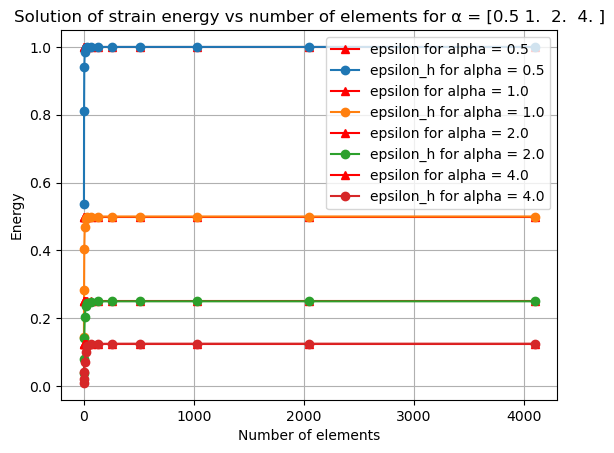

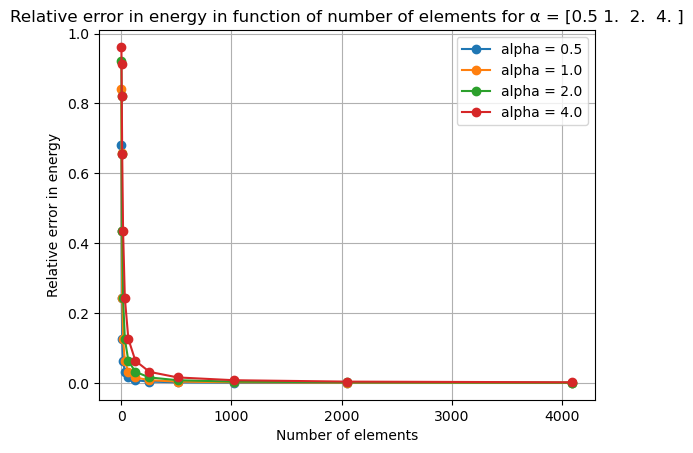

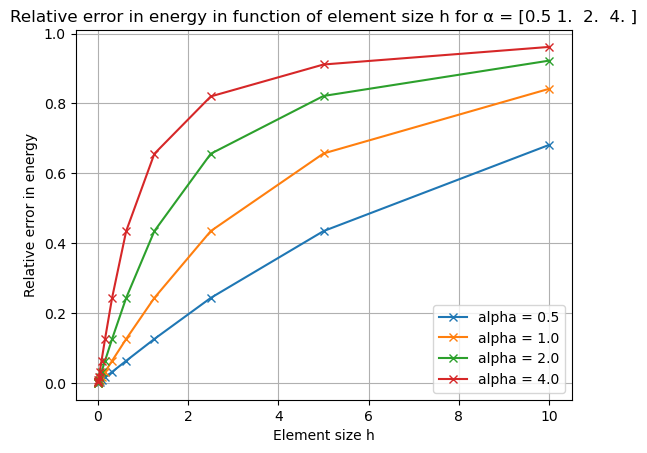

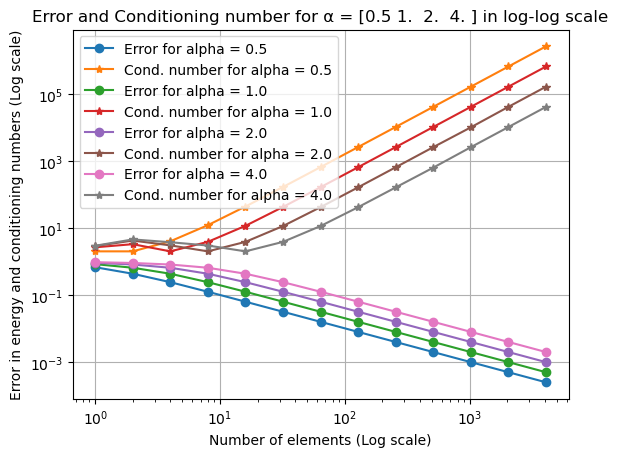

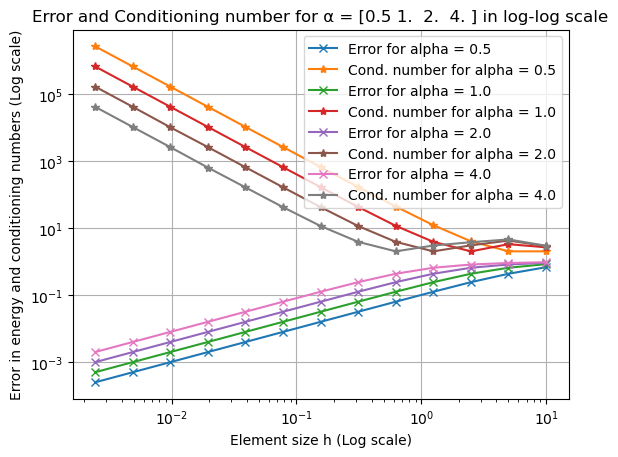

- Convergence rate for alpha = 0.5: 1.0000
- Convergence rate for alpha = 1.0: 1.0000
- Convergence rate for alpha = 2.0: 1.0000
- Convergence rate for alpha = 4.0: 0.9999


In [5]:
#!/usr/bin/env python

import numpy as np
import scipy.sparse.linalg as spla

import pyfem

def main(use_sparse: bool = False) -> None:
    # PREPROCESSING

    # 1. Geometry and discretization

    # Problem parameters
    L = 10.0
    number_elements = np.zeros(13)
    for n in range(0, 13):
        number_elements[n] = 2**n
    h = L / number_elements
    P = 1.0
    E = 1.0
    A = 1.0
    alpha_values = np.array([0.5, 1.0, 2.0, 4.0])

    # Initialization of the vectors before the cicles
    epsilon = np.zeros((len(alpha_values), len(number_elements)))
    epsilon_h = np.zeros((len(alpha_values), len(number_elements)))
    e = np.zeros((len(alpha_values), len(number_elements)))
    cond_numbers = np.zeros((len(alpha_values), len(number_elements)))

    for alpha in alpha_values:
        alpha_counter = np.where(alpha_values == alpha)[0][0]

        # 2. Element properties

        # Define element properties registry
        element_properties = pyfem.make_element_properties(
            [
                ("bar", ("bar_1D", {"E": E, "A": A, "k": alpha**2 * E * A})),
            ]
        )

        for Ne in number_elements:
            num_elements = int(Ne)

            # Found the position in number_elements of num_elements
            i = np.where(number_elements == num_elements)[0][0]

            # Assign properties to elements
            element_property_labels = ["bar"] * num_elements

            # Nodes and points calculation
            num_nodes = int(Ne + 1)
            points = np.linspace(0.0, 10.0, num_nodes)

            # Connectivity generation
            element_connectivity = connectivity_2nodes_per_element(int(Ne))

            # 3. Mesh

            # Create mesh
            mesh = pyfem.Mesh(
                num_nodes=num_nodes,
                points=points,
                num_elements=num_elements,
                element_connectivity=element_connectivity,
                element_property_labels=element_property_labels,
            )

            # Define node sets
            mesh.add_node_set(tag=1, nodes={0}, name="left_end")
            mesh.add_node_set(tag=2, nodes={num_nodes - 1}, name="right_end")

            # 4. Create Model

            problem = pyfem.Problem(
                pyfem.Physics.MECHANICS,
                pyfem.Dimension.D1,
            )

            model = pyfem.Model(mesh, problem)
            model.set_element_properties(element_properties)

            # 5. Boundary conditions

            # Dirichlet boundary conditions (prescribed displacements)
            model.bc.prescribe_displacement(
                "right_end",
                pyfem.DOFType.U_X,
                (-(P / (E * A * alpha)) * np.exp(-alpha * 10.0)),
            )

            # Neumann boundary conditions (applied forces)
            model.bc.apply_force("left_end", pyfem.DOFType.U_X, -P)

            # PROCESSING: Solve FEA problem

            # Create solver
            solver = pyfem.LinearStaticSolver(model)

            # Assemble the global stiffness matrix
            solver.assemble_global_matrix()

            # Apply boundary conditions
            solver.apply_boundary_conditions()

            # Solve for nodal displacements
            solver.solve()

            # POSTPROCESSING: Compute derived quantities

            # Create postprocessor
            postprocessor = pyfem.PostProcessor(
                model.mesh,
                model.element_properties,
                solver.global_stiffness_matrix,
                solver.nodal_displacements,
                number_elements,
                alpha,
                alpha_counter,
                alpha_values,
                E,
                A,
                P,
            )

            # Compute strain energy using the global solution (U = 0.5 * u^T * K * u)
            epsilon_h = postprocessor.compute_strain_energy_global(i, epsilon_h)

            # Compute the analytical strain energy
            epsilon = postprocessor.compute_strain_energy_analytical(i, epsilon)

            # Computes the relative error in the energy norm
            e = postprocessor.compute_relative_error_in_energy(i, epsilon, epsilon_h, e)

            # Compute the conditioning number of K
            cond_numbers = conditioning_numbers_of_K(
                alpha_counter, cond_numbers, solver.global_stiffness_matrix, i
            )

    # Plots the solution of the energy
    postprocessor.plot_solution(epsilon, epsilon_h)
    # Plots the relative error in the energy
    postprocessor.plot_e(e, h)
    # Plots the relative error in the energy
    postprocessor.plot_convergence_rate(e, h, cond_numbers)
    # Compute the convergence rate
    postprocessor.calculate_convergence_rates(e, h, is_dofs=False)


if __name__ == "__main__":
    main(use_sparse=False)


### bar_1D with 3 nodes

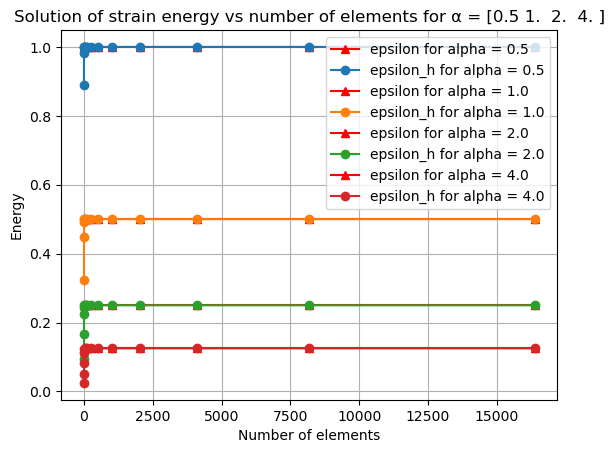

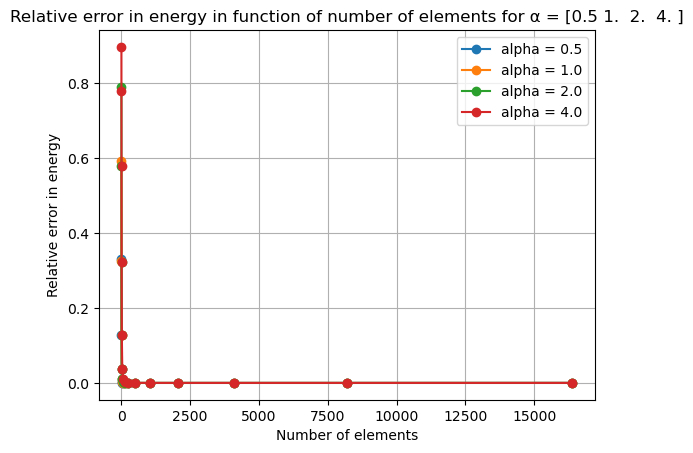

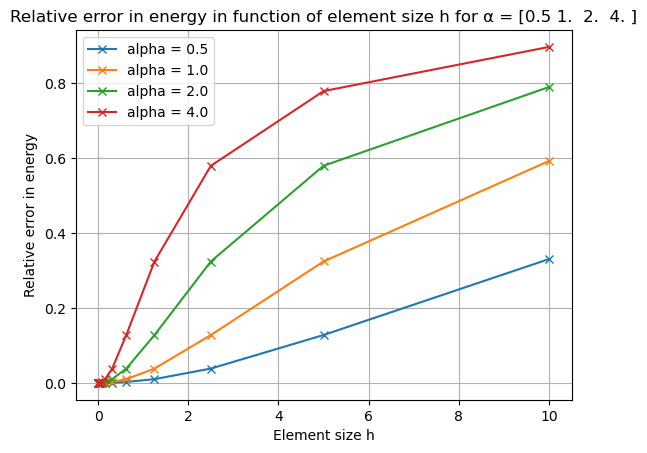

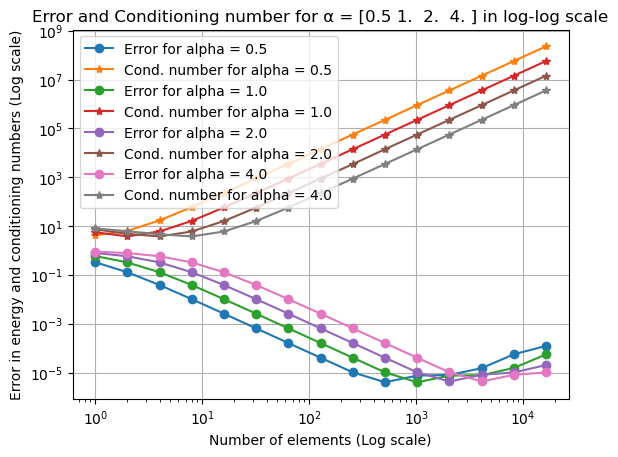

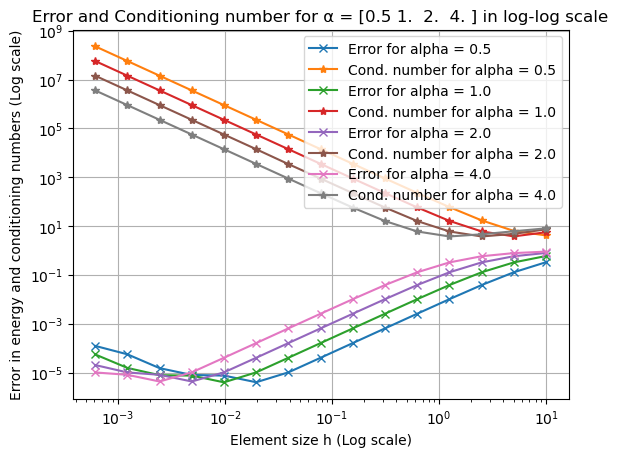

- Convergence rate for alpha = 0.5: 1.9855
- Convergence rate for alpha = 1.0: 1.9879
- Convergence rate for alpha = 2.0: 1.9842
- Convergence rate for alpha = 4.0: 1.9842


In [ ]:
#!/usr/bin/env python

import numpy as np
import scipy.sparse.linalg as spla

import pyfem

def main(use_sparse: bool = True) -> None:
    # PREPROCESSING

    # 1. Geometry and discretization

    # Problem parameters
    L = 10.0
    number_elements = np.zeros(15)
    for n in range(0, 15):
        number_elements[n] = 2**n
    h = L / number_elements
    P = 1.0
    E = 1.0
    A = 1.0
    alpha_values = np.array([0.5, 1.0, 2.0, 4.0])

    # Initialization of the vectors before the cicles
    epsilon = np.zeros((len(alpha_values), len(number_elements)))
    epsilon_h = np.zeros((len(alpha_values), len(number_elements)))
    e = np.zeros((len(alpha_values), len(number_elements)))
    cond_numbers = np.zeros((len(alpha_values), len(number_elements)))

    for alpha in alpha_values:
        alpha_counter = np.where(alpha_values == alpha)[0][0]
        # 2. Element properties

        # Define element properties registry
        element_properties = pyfem.make_element_properties(
            [
                ("bar", ("bar3_1D", {"E": E, "A": A, "k": alpha**2 * E * A})),
            ]
        )

        for Ne in number_elements:
            num_elements = int(Ne)
            # Found the position in number_elements of num_elements
            i = np.where(number_elements == num_elements)[0][0]

            # Assign properties to elements
            element_property_labels = ["bar"] * num_elements

            # Nodes and points calculation
            num_nodes = int((2.0 * Ne) + 1)
            points = np.linspace(0.0, 10.0, num_nodes)

            # Connectivity generation
            element_connectivity = connectivity_3nodes_per_element(int(Ne))

            # 3. Mesh

            # Create mesh
            mesh = pyfem.Mesh(
                num_nodes=num_nodes,
                points=points,
                num_elements=num_elements,
                element_connectivity=element_connectivity,
                element_property_labels=element_property_labels,
            )

            # Define node sets
            mesh.add_node_set(tag=1, nodes={0}, name="left_end")
            mesh.add_node_set(tag=2, nodes={num_nodes - 1}, name="right_end")

            # print("\n- Node sets:")
            #
            # for tag, node_set in mesh.node_sets.items():
            #     print(f"  {node_set}")

            # 4. Create Model

            problem = pyfem.Problem(
                pyfem.Physics.MECHANICS,
                pyfem.Dimension.D1,
            )

            model = pyfem.Model(mesh, problem)
            model.set_element_properties(element_properties)
            # print(model)

            # 5. Boundary conditions

            # Dirichlet boundary conditions (prescribed displacements)
            model.bc.prescribe_displacement(
                "right_end",
                pyfem.DOFType.U_X,
                (-(P / (E * A * alpha)) * np.exp(-alpha * 10.0)),
            )

            # Neumann boundary conditions (applied forces)
            model.bc.apply_force("left_end", pyfem.DOFType.U_X, -P)

            # print(f"\n- Prescribed displacements: {model.bc.prescribed_displacements}")
            # print(f"- Applied forces: {model.bc.applied_forces}")

            # PROCESSING: Solve FEA problem

            # Create solver
            solver = pyfem.LinearStaticSolver(model)

            # Assemble the global stiffness matrix
            solver.assemble_global_matrix()

            # Apply boundary conditions
            solver.apply_boundary_conditions()

            # Solve for nodal displacements
            solver.solve()

            # POSTPROCESSING: Compute derived quantities

            # Create postprocessor
            postprocessor = pyfem.PostProcessor(
                model.mesh,
                model.element_properties,
                solver.global_stiffness_matrix,
                solver.nodal_displacements,
                number_elements,
                alpha,
                alpha_counter,
                alpha_values,
                E,
                A,
                P,
            )

            # Compute strain energy using the global solution (U = 0.5 * u^T * K * u)
            epsilon_h = postprocessor.compute_strain_energy_global(i, epsilon_h)

            # Compute the analytical strain energy
            epsilon = postprocessor.compute_strain_energy_analytical(i, epsilon)

            # Computes the relative error in the energy norm
            e = postprocessor.compute_relative_error_in_energy(i, epsilon, epsilon_h, e)

            # Compute the conditioning number of K
            cond_numbers = conditioning_numbers_of_K(
                alpha_counter, cond_numbers, solver.global_stiffness_matrix, i
            )

    # Plots the solution of the energy
    postprocessor.plot_solution(
        epsilon,
        epsilon_h,
    )
    # Plots the relative error in the energy
    postprocessor.plot_e(e, h)
    # Plots the relative error in the energy
    postprocessor.plot_convergence_rate(e, h, cond_numbers)
    # Compute the convergence rate
    postprocessor.calculate_convergence_rates(e, h, is_dofs=False)


if __name__ == "__main__":
    main(use_sparse=False)


**Considerations and results**

The parameter $\alpha$ relates the stiffness of the surrounding medium $k$ to the axial stiffness of the bar $EA$. <br>
A higher value of $\alpha$ indicates a stiffer medium relative to the bar, which localizes the deformation and creates a much sharper and narrower boundary layer near the point of load application ($x=0$). <br>
Observing the log-log convergence plots, it is evident that when $\alpha$ increases from $0.5$ to $4.0$, the error curves are shifted vertically upwards. <br>
A higher $\alpha$ produces an increased displacement gradient near the origin, and an uniform mesh struggles to capture this abrupt localized variation. This cause that for any given element size h, the interpolation error within the elements closest to the load application point is significantly larger for higher values of $\alpha$.

The parameter $\alpha$ dictates when the mesh enters in the asymptotic regime. <br>
In particular, for low values ($\alpha=0.5$), the displacement field is smoother, and the finite element solution achieves the theoretical convergence slope almost immediately, even with coarse meshes. <br>
Instead, for high values ($\alpha=4.0$), the sharp boundary layer extends the pre-asymptotic phase, and the mesh must be refined considerably more before the log-log plot exhibits the constant, theoretical asymptotic slope.

Linear elements (2 nodes) assume a constant strain (constant u') within each element. They perform poorly when forced to approximate the steep.
Quadratic elements (3 nodes) still suffer an initial accuracy penalty at high $\alpha$ values but they transition into the asymptotic convergence regime faster and capture the boundary layer with far fewer degrees of freedom compared to the linear ones.

## **TASK 6**

### bar_1D with 3 nodes

To resolve Task 6 regarding, the following strategies are proposed and analyzed:


1. Polynomial Degree Refinement (p-refinement)

Instead of only increase the number of elements, this strategy involves increasing the order of the shape functions (e.g., transitioning from linear 2-node elements to quadratic 3-node elements or higher).
Higher-order elements are mathematically better suited to capture the curvature of the exponential solution $u(x) \propto \exp(-\alpha x)$. <br>
This is already demonstrated in the previous tasks, that compare the solution obtained by two and three nodes elements.


2. Graded/Non-uniform Mesh Refinement

This is the most effective strategy for problems characterized by a boundary layer near a specific point. Rather than using elements of uniform size $h$, the mesh is refined by increasing elements near $x=0$, where the solution gradient is maximum. <br>
A power-law distribution for node coordinates is utilized, with the coordinate x_i of the i-th node is defined as:$$x_i = L \cdot \left( \frac{i}{n_{elem}} \right)^r$$ <br> where $r > 1$ is a "shaping" or "grading" parameter. For $r > 1$, a higher density of elements is placed near the origin. <br>
This is shown in code and plots below.

C:\Users\bolzo\Desktop\FEM\pyFEM-repository\PYFEM\pyfem\post_processor.py:155: RuntimeWarning: invalid value encountered in scalar power
  e[alpha_counter, i] = (


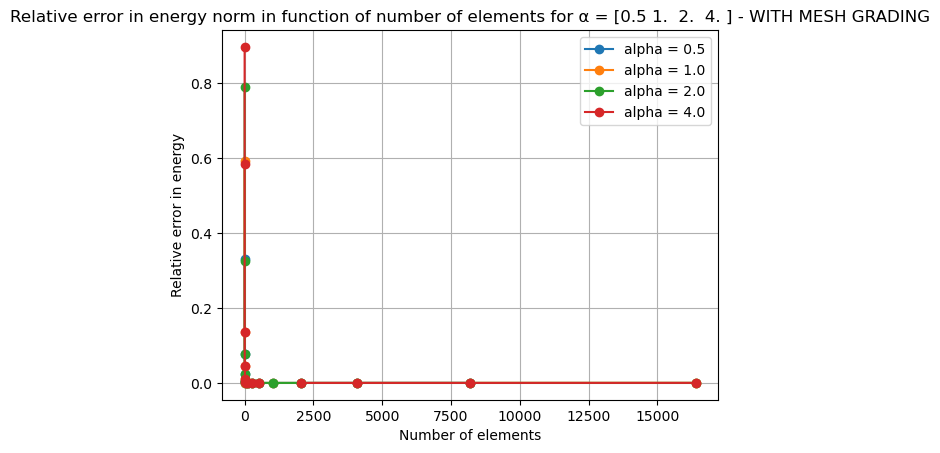

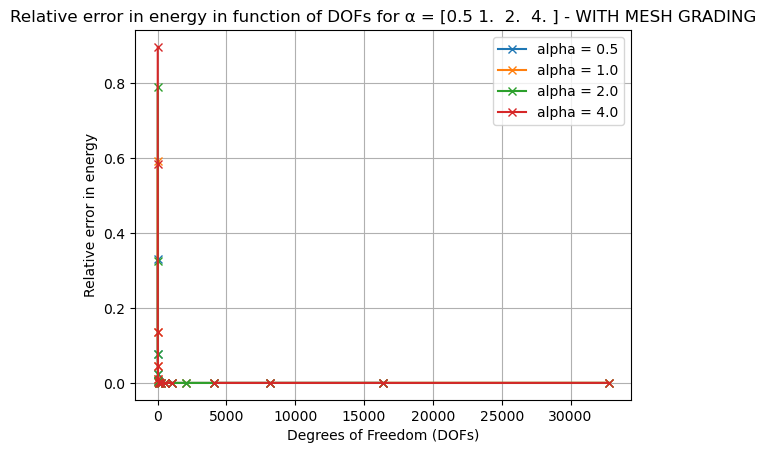

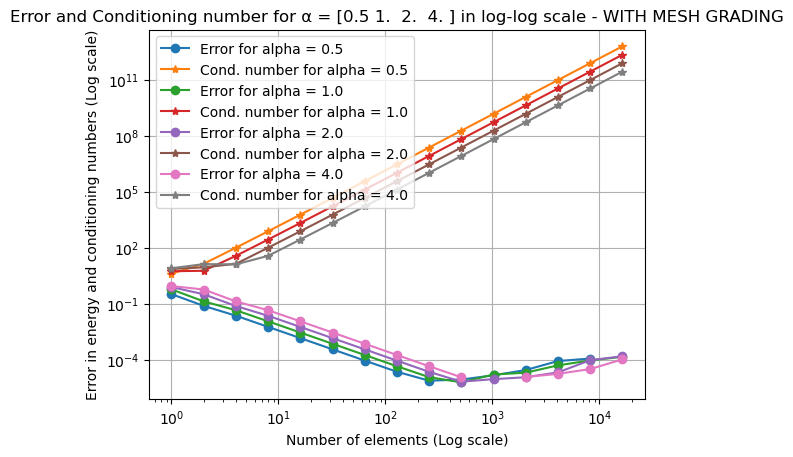

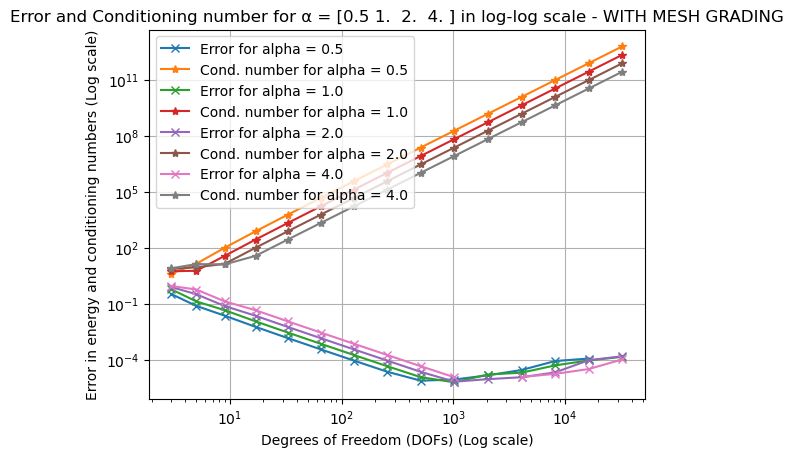

- Convergence rate for alpha = 0.5: 2.0007
- Convergence rate for alpha = 1.0: 1.9481
- Convergence rate for alpha = 2.0: 2.0018
- Convergence rate for alpha = 4.0: 2.0046


In [15]:
#!/usr/bin/env python

import numpy as np
import scipy.sparse.linalg as spla

import pyfem

def main(use_sparse: bool = True) -> None:
    # PREPROCESSING

    # 1. Geometry and discretization

    # Problem parameters
    L = 10.0
    number_elements = np.zeros(15)
    for n in range(0, 15):
        number_elements[n] = 2**n
    dofs_array = (
        2.0 * number_elements
    ) + 1.0  # Degrees of freedom array computation (DOFs) for 3-node elements
    P = 1.0
    E = 1.0
    A = 1.0
    alpha_values = np.array([0.5, 1.0, 2.0, 4.0])

    # Initialization of the vectors before the cicles
    epsilon = np.zeros((len(alpha_values), len(number_elements)))
    epsilon_h = np.zeros((len(alpha_values), len(number_elements)))
    e = np.zeros((len(alpha_values), len(number_elements)))
    cond_numbers = np.zeros((len(alpha_values), len(number_elements)))

    for alpha in alpha_values:
        alpha_counter = np.where(alpha_values == alpha)[0][0]
        # 2. Element properties

        # Define element properties registry
        element_properties = pyfem.make_element_properties(
            [
                ("bar", ("bar3_1D", {"E": E, "A": A, "k": alpha**2 * E * A})),
            ]
        )

        for Ne in number_elements:
            num_elements = int(Ne)
            # Found the position in number_elements of num_elements
            i = np.where(number_elements == num_elements)[0][0]

            # Assign properties to elements
            element_property_labels = ["bar"] * num_elements

            # Nodes and points calculation
            num_nodes = int((2.0 * Ne) + 1)

            # Graded Mesh Generation
            r = 2.0  # Grading parameter (r > 1 refines near x=0, r=1 uniform mesh)

            xi = np.linspace(
                0.0, 1.0, num_nodes
            )  # uniformly distributed points in the parametric space [0, 1]

            points = L * (
                xi**r
            )  # Apply power-law mapping to physical space [0, L] with grading

            # Connectivity generation
            element_connectivity = connectivity_3nodes_per_element(int(Ne))

            # 3. Mesh

            # Create mesh
            mesh = pyfem.Mesh(
                num_nodes=num_nodes,
                points=points,
                num_elements=num_elements,
                element_connectivity=element_connectivity,
                element_property_labels=element_property_labels,
            )

            # Define node sets
            mesh.add_node_set(tag=1, nodes={0}, name="left_end")
            mesh.add_node_set(tag=2, nodes={num_nodes - 1}, name="right_end")

            # 4. Create Model

            problem = pyfem.Problem(
                pyfem.Physics.MECHANICS,
                pyfem.Dimension.D1,
            )

            model = pyfem.Model(mesh, problem)
            model.set_element_properties(element_properties)

            # 5. Boundary conditions

            # Dirichlet boundary conditions (prescribed displacements)
            model.bc.prescribe_displacement(
                "right_end",
                pyfem.DOFType.U_X,
                (-(P / (E * A * alpha)) * np.exp(-alpha * 10.0)),
            )

            # Neumann boundary conditions (applied forces)
            model.bc.apply_force("left_end", pyfem.DOFType.U_X, -P)

            # PROCESSING: Solve FEA problem

            # Create solver
            solver = pyfem.LinearStaticSolver(model)

            # Assemble the global stiffness matrix
            solver.assemble_global_matrix()

            # Apply boundary conditions
            solver.apply_boundary_conditions()

            # Solve for nodal displacements
            solver.solve()

            # POSTPROCESSING: Compute derived quantities

            # Create postprocessor
            postprocessor = pyfem.PostProcessor(
                model.mesh,
                model.element_properties,
                solver.global_stiffness_matrix,
                solver.nodal_displacements,
                number_elements,
                alpha,
                alpha_counter,
                alpha_values,
                E,
                A,
                P,
            )

            # Compute strain energy using the global solution (U = 0.5 * u^T * K * u)
            epsilon_h = postprocessor.compute_strain_energy_global(i, epsilon_h)

            # Compute the analytical strain energy
            epsilon = postprocessor.compute_strain_energy_analytical(i, epsilon)

            # Computes the relative error in the energy norm
            e = postprocessor.compute_relative_error_in_energy(i, epsilon, epsilon_h, e)

            # Compute the conditioning number of K
            cond_numbers = conditioning_numbers_of_K(
                alpha_counter, cond_numbers, solver.global_stiffness_matrix, i
            )

    # Plots the relative error in the energy
    postprocessor.plot_e_grading(e, dofs_array)
    # Plots the relative error in the energy
    postprocessor.plot_convergence_rate_grading(e, dofs_array, cond_numbers)
    # Compute the convergence rate
    postprocessor.calculate_convergence_rates(e, dofs_array, is_dofs=True)


if __name__ == "__main__":
    main(use_sparse=False)


### **Observations and results**

By concentrating the element density near $x=0$, the graded mesh neutralizes the effect of the boundary layer and the numerical solver perfectly recovers the theoretical asymptotic convergence rate of $2.00$ (e.g., $2.0046$ for $\alpha = 4.0$). The mesh now correctly captures the mathematical behavior of the quadratic shape functions.

An other metric of success for an adaptive or graded mesh strategy is the reduction of the computational cost.
Infact considering the most severe case ($\alpha = 4.0$), the uniform mesh requires approximately $6 \cdot 10^3$ DOFs to reach the minimum machine-achievable error bound of $\approx 10^{-5}$. Instead, the graded mesh attains the exact same level of accuracy utilizing fewer than $10^3$ DOFs. The graded mesh achieves the maximum possible mathematical precision utilizing less than a fraction of the computational resources, showing a much higher DOF-to-accuracy ratio.